# Qwen2.5-Coder-14B-Instruct —  Evaluation

Runs the 14B model with no fine-tuning through the same Spider pipeline as the 3B experiments to give us a comparison



In [1]:
import torch
from google.colab import drive

assert torch.cuda.is_available(), 'Enable a GPU runtime first.'
print('GPU:', torch.cuda.get_device_name(0))
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
drive.mount('/content/drive')


GPU: NVIDIA A100-SXM4-40GB
VRAM: 39.5 GB
Mounted at /content/drive


In [2]:
from google.colab import userdata
from pathlib import Path
import os, sys, shutil, subprocess, zipfile

REPO_DIR = Path('/content/msc_project')
REPO_URL = 'https://git.cs.bham.ac.uk/txh517/msc_project.git'
username = userdata.get('GITLAB_USERNAME')
token = userdata.get('GITLAB_TOKEN')
assert username and token, 'Add GITLAB_USERNAME and GITLAB_TOKEN in Colab Secrets.'

os.chdir('/content')
shutil.rmtree(REPO_DIR, ignore_errors=True)
askpass = Path('/content/git_askpass.sh')
askpass.write_text('#!/bin/sh\ncase "$1" in\n  *Username*) echo "$GITLAB_USERNAME" ;;\n  *Password*) echo "$GITLAB_TOKEN" ;;\nesac\n')
askpass.chmod(0o700)
env = os.environ.copy()
env.update({'GIT_ASKPASS': str(askpass), 'GIT_TERMINAL_PROMPT': '0', 'GITLAB_USERNAME': username, 'GITLAB_TOKEN': token})
subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], env=env, check=True)
askpass.unlink(missing_ok=True)

req = REPO_DIR / 'requirements.txt'
if req.exists():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(req)], check=True)

SPIDER_DIR = REPO_DIR / 'data' / 'spider'
SPIDER_ZIP = Path('/content/drive/MyDrive/spider_data.zip')
required = [SPIDER_DIR / 'dev.json', SPIDER_DIR / 'tables.json', SPIDER_DIR / 'database']

if not all(p.exists() for p in required):
    assert SPIDER_ZIP.exists(), f'Missing {SPIDER_ZIP}'
    SPIDER_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(SPIDER_ZIP) as z:
        z.extractall(SPIDER_DIR)
    for nested in [SPIDER_DIR / 'spider_data', SPIDER_DIR / 'spider', SPIDER_DIR / 'spider_data' / 'spider']:
        if (nested / 'dev.json').exists():
            for item in nested.iterdir():
                target = SPIDER_DIR / item.name
                if not target.exists():
                    shutil.move(str(item), str(target))
            break

assert all(p.exists() for p in required), 'Spider files were not prepared correctly.'
os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))
print('Ready:', REPO_DIR)


Ready: /content/msc_project


In [3]:
import json
from dataclasses import asdict
from pathlib import Path
from common.config import load_config
from common.data_loader import load_examples
from common.model import load_slm, make_generator
from common.runner import run_evaluation

MODEL_NAME = 'Qwen/Qwen2.5-Coder-14B-Instruct'
OUTPUT = Path('/content/drive/MyDrive/msc_text_to_sql/results/slm_vanilla_14b.json')
SAVE_EVERY = 10

cfg = load_config()
examples = load_examples(cfg['paths']['dev_json'])
records = json.loads(OUTPUT.read_text()) if OUTPUT.exists() else []

for saved, ex in zip(records, examples):
    assert (saved['db_id'], saved['question'], saved['gold_sql']) == (ex.db_id, ex.question, ex.gold_sql)

print(f'Already complete: {len(records)}/{len(examples)}')
model, tokenizer = load_slm(MODEL_NAME, device='cuda')
generate_fn = make_generator(model, tokenizer, max_new_tokens=cfg['generation']['max_new_tokens'], temperature=cfg['generation']['temperature'])

for start in range(len(records), len(examples), SAVE_EVERY):
    chunk = examples[start:start + SAVE_EVERY]
    new = run_evaluation(chunk, generate_fn, tables_json=cfg['paths']['tables_json'], database_dir=cfg['paths']['database_dir'], schema_style=cfg['prompt']['schema_style'], include_keys=cfg['prompt']['include_keys'])
    records.extend(asdict(r) for r in new)
    OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    OUTPUT.write_text(json.dumps(records, indent=2), encoding='utf-8')
    correct = sum(bool(r['correct']) for r in records)
    print(f'[{len(records)}/{len(examples)}] running EX = {correct/len(records):.2%}')

print('Finished:', OUTPUT)


Already complete: 0/1034


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

[10/1034] running EX = 90.00%
[20/1034] running EX = 80.00%
[30/1034] running EX = 83.33%
[40/1034] running EX = 82.50%
[50/1034] running EX = 84.00%
[60/1034] running EX = 85.00%
[70/1034] running EX = 84.29%
[80/1034] running EX = 80.00%
[90/1034] running EX = 81.11%
[100/1034] running EX = 81.00%
[110/1034] running EX = 79.09%
[120/1034] running EX = 76.67%
[130/1034] running EX = 74.62%
[140/1034] running EX = 73.57%
[150/1034] running EX = 72.67%
[160/1034] running EX = 70.62%
[170/1034] running EX = 69.41%
[180/1034] running EX = 67.78%
[190/1034] running EX = 68.42%
[200/1034] running EX = 70.00%
[210/1034] running EX = 71.43%
[220/1034] running EX = 72.27%
[230/1034] running EX = 71.30%
[240/1034] running EX = 71.25%
[250/1034] running EX = 72.40%
[260/1034] running EX = 73.46%
[270/1034] running EX = 72.96%
[280/1034] running EX = 73.93%
[290/1034] running EX = 74.14%
[300/1034] running EX = 75.00%
[310/1034] running EX = 75.16%
[320/1034] running EX = 75.94%
[330/1034] runnin

In [4]:
correct = sum(bool(r['correct']) for r in records)
total = len(records)
ex = correct / total
print(f'14B vanilla: {correct}/{total} = {ex:.2%}')
print('\nCurrent comparison')
print('3B vanilla : 62.57%')
print('3B + IA3   : 70.79%')
print('3B + LoRA  : 71.47%')
print(f'14B vanilla: {ex:.2%}')


14B vanilla: 781/1034 = 75.53%

Current comparison
3B vanilla : 62.57%
3B + IA3   : 70.79%
3B + LoRA  : 71.47%
14B vanilla: 75.53%


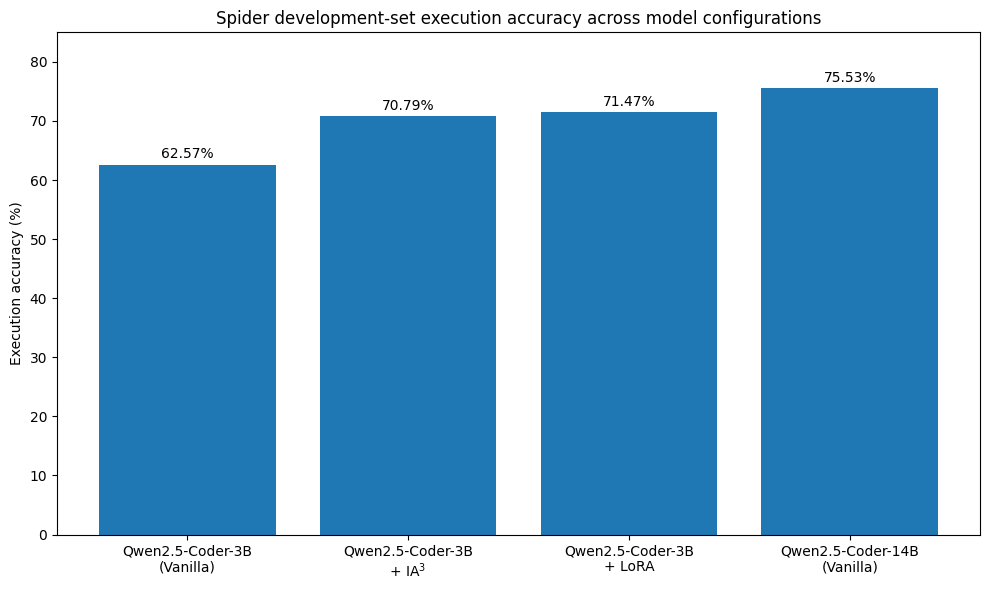

In [5]:
import matplotlib.pyplot as plt

# Data
models = [
    "Qwen2.5-Coder-3B\n(Vanilla)",
    "Qwen2.5-Coder-3B\n+ IA$^3$",
    "Qwen2.5-Coder-3B\n+ LoRA",
    "Qwen2.5-Coder-14B\n(Vanilla)"
]

accuracies = [62.57, 70.79, 71.47, 75.53]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies)

plt.ylabel("Execution accuracy (%)")
plt.title("Spider development-set execution accuracy across model configurations")
plt.ylim(0, 85)

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{acc:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

# Save high-quality figure
plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()